A financial institution loans data to people and want to mitigate loss by predicting customers that may default payment based oh available historical data.
The objective of this machine learning is to predict lendee that will default and the probablity of default

In [ ]:
pip install  pandas numpy matplotlib seaborn pipeline scikit-learn plotly

Importing data from google drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
import pandas as pd
file_path = '/content/drive/My Drive/Data Science Projects/Credit_Card_Churn/UCI_Credit_Card.csv'
df= pd.read_csv(file_path)
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


Data Cleaning and Exploration

In [4]:
len(df)

30000

In [5]:
# checking for duplicates on id column
df.duplicated(subset='ID').sum()
df['ID'].isnull().sum()
# The UndefinedMetricWarning you observed is related to how sklearn calculates metrics when a model makes no positive predictions.
# This specific warning comes from cell 'h-469Ysm2zKs' where 'precision_score', 'recall_score', and 'f1_score' are used.
# To handle it, you can set the `zero_division` parameter in those metric functions (e.g., `precision_score(y_true, y_pred, zero_division=0)`).
# Since this cell ('0pY6F_9mani3') is for data cleaning checks, no changes are needed here to resolve that specific warning.

np.int64(0)

In [ ]:
df.isnull().sum().all()

np.False_

Data Visualisation

Histogram of Limit balance

In [ ]:
import plotly.express as px
fig= px.histogram(df,x='LIMIT_BAL',nbins=50)
fig.update_layout(title='Distribution of Limit balance', template='plotly_dark')
fig.show()

Count of churn by gender

In [ ]:
df['Sex_mapping'] = df['SEX'].map({1:'Male',2:'Female'})


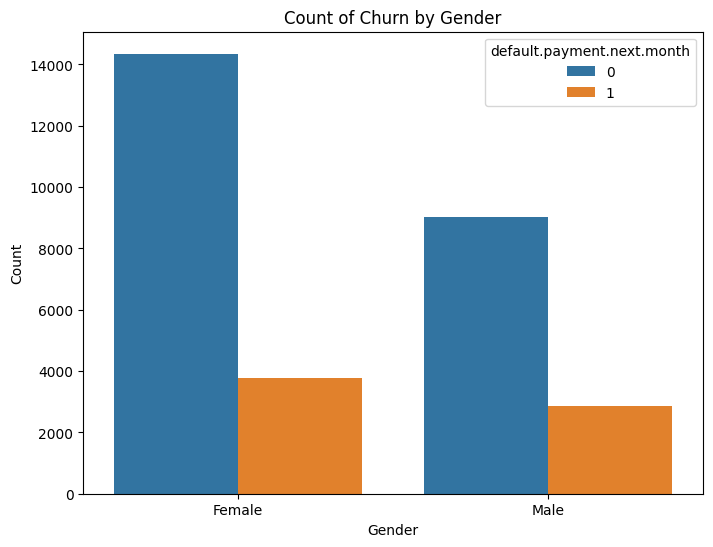

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
sns.countplot(x='Sex_mapping',hue='default.payment.next.month',data=df)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Count of Churn by Gender')
plt.show()


Lendee age distribution

In [ ]:
fig= px.histogram(df,x='AGE',nbins=20)
fig.update_layout(title='Distribution of Lendee Age', template='plotly_dark')
fig.show()

Count of churn by marriage status

In [ ]:
df['Marriage_mapping'] = df['MARRIAGE'].map({1:'Married',2:'Single',3:'Other'})


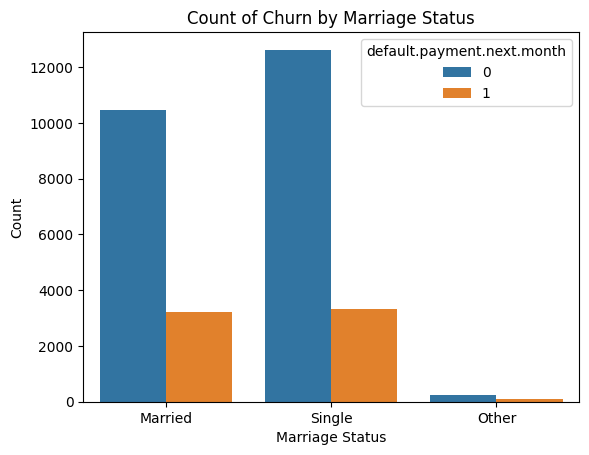

In [ ]:
sns.countplot(x='Marriage_mapping',hue='default.payment.next.month',data=df)
plt.xlabel('Marriage Status')
plt.ylabel('Count')
plt.title('Count of Churn by Marriage Status')
plt.show()

Viweing outliers using box plot

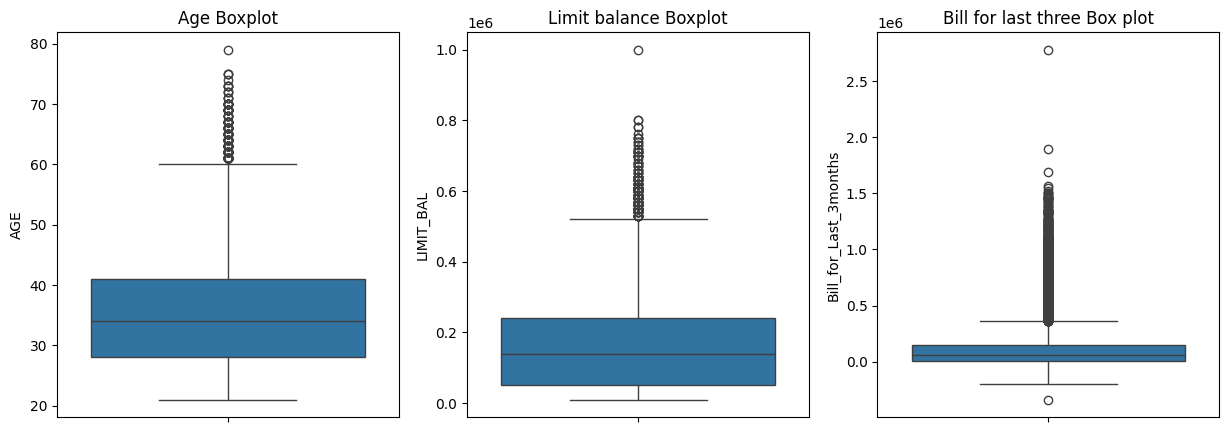

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1,3,1)
sns.boxplot(df, y='AGE')
plt.title('Age Boxplot')

plt.subplot(1,3,2)
sns.boxplot(df, y='LIMIT_BAL')
plt.title('Limit balance Boxplot')

plt.subplot(1,3,3)
sns.boxplot(df, y='Bill_for_Last_3months')
plt.title('Bill for last three Box plot')

plt.show()


 Numeric Feature selection using Factor Analyser

In [24]:
extracted_df = df.drop(columns=['default.payment.next.month'])

In [ ]:
pip install factor_analyzer

In [25]:
#Feature selection for numerical_features
from factor_analyzer import FactorAnalyzer
from sklearn.preprocessing import StandardScaler

# Scale the numerical data
scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(extracted_df)

# Initialize and fit FactorAnalyzer with 5 factors
fa = FactorAnalyzer(n_factors=5, rotation='varimax', method='ml') # 'varimax' for orthogonal rotation
fa.fit(numeric_scaled)

# Get loadings
loadings = pd.DataFrame(fa.loadings_, index=extracted_df.columns, columns=[f'Factor{i+1}' for i in range(5)])
print("Factor loadings:\n", loadings.round(3))

# Communalities (how much variance each variable explains)
communalities = pd.Series(fa.get_communalities(), index=extracted_df.columns)
print("\nCommunalities:\n", communalities.round(3))

# Select variables with strong loadings (absolute value > 0.5 on any factor)
selected_vars = loadings[loadings.abs().max(axis=1) > 0.5].index.tolist()
print("\nVariables chosen by factor analysis (|loading| > 0.5):\n")
print(selected_vars)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Factor loadings:
            Factor1  Factor2  Factor3  Factor4  Factor5
ID           0.021   -0.021    0.015   -0.003    0.021
LIMIT_BAL    0.293   -0.356    0.282    0.150    0.075
SEX         -0.015   -0.069   -0.014    0.020    0.014
EDUCATION    0.011    0.126   -0.071   -0.079   -0.027
MARRIAGE    -0.032    0.048   -0.003   -0.008   -0.009
AGE          0.060   -0.071    0.036    0.006    0.007
PAY_0        0.138    0.619   -0.160   -0.064   -0.058
PAY_2        0.158    0.755   -0.134   -0.065   -0.054
PAY_3        0.129    0.830   -0.059   -0.039   -0.035
PAY_4        0.107    0.893   -0.018    0.006    0.054
PAY_5        0.107    0.881    0.012    0.080    0.049
PAY_6        0.126    0.807   -0.001    0.129    0.036
BILL_AMT1    0.918    0.127    0.200   -0.088   -0.090
BILL_AMT2    0.936    0.153    0.281   -0.084   -0.095
BILL_AMT3    0.929    0.151    0.193   -0.061    0.259
BILL_AMT4    0.909    0.162    0.157    0.178    0.132
BILL_AMT5    0.907    0.157    0.090    0.364  

Model training

In [26]:
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

In [17]:
pip install Xgboost


In [41]:
best_numerical_features = extracted_df[['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2']]
X= best_numerical_features
y= df['default.payment.next.month']

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

Logistic regression model

In [43]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

In [44]:
pipeline.fit(X_train, y_train)
logistic_prediction_prob = pipeline.predict_proba(X_test)
logistic_prediction = pipeline.predict(X_test)
print(classification_report(y_test, logistic_prediction))
print(confusion_matrix(y_test, logistic_prediction))


              precision    recall  f1-score   support

           0       0.82      0.97      0.89      7040
           1       0.69      0.22      0.33      1960

    accuracy                           0.81      9000
   macro avg       0.75      0.60      0.61      9000
weighted avg       0.79      0.81      0.77      9000

[[6848  192]
 [1533  427]]


Xgboost_Model

In [45]:
from xgboost import XGBClassifier

Xgboost_model = XGBClassifier(n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
).fit(X_train,y_train)
Xgboost_model.fit(X_train, y_train)
Xgboost_prediction = Xgboost_model.predict(X_test)
Xgboost_prediction_prob = Xgboost_model.predict_proba(X_test)
print(classification_report(y_test, Xgboost_prediction))
print(confusion_matrix(y_test, Xgboost_prediction))

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      7040
           1       0.66      0.36      0.46      1960

    accuracy                           0.82      9000
   macro avg       0.75      0.65      0.68      9000
weighted avg       0.80      0.82      0.80      9000

[[6675  365]
 [1259  701]]


In [46]:

Random_forest_model=RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=5, min_samples_leaf=3, max_features='sqrt',random_state=42)
Random_forest_model.fit(X_train, y_train)
Random_forest_prediction = Random_forest_model.predict(X_test)
Random_forest_prediction_prob = Random_forest_model.predict_proba(X_test)
print(classification_report(y_test, Random_forest_prediction))
print(confusion_matrix(y_test, Random_forest_prediction))


              precision    recall  f1-score   support

           0       0.84      0.95      0.89      7040
           1       0.66      0.35      0.46      1960

    accuracy                           0.82      9000
   macro avg       0.75      0.65      0.68      9000
weighted avg       0.80      0.82      0.80      9000

[[6685  355]
 [1267  693]]


Comparing models

In [34]:
models = {
    "Logistic Regression": logistic_prediction,
    "XGBoost": Xgboost_prediction,
    "Random Forest": Random_forest_prediction
}



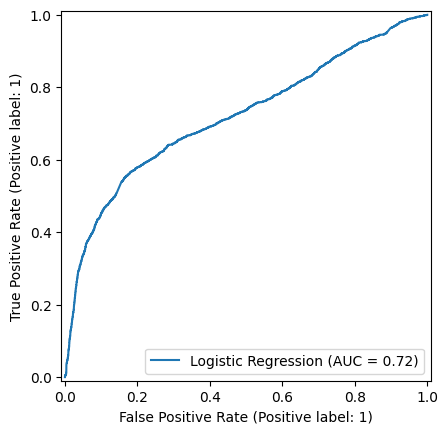

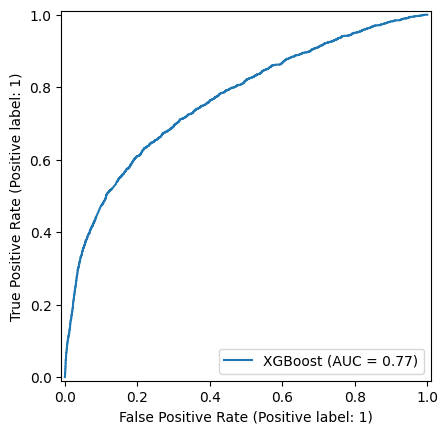

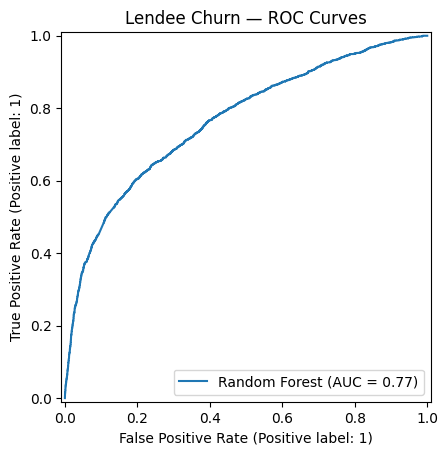

In [35]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# Redefine models to contain the actual fitted estimators
models = {
    "Logistic Regression": pipeline,
    "XGBoost": Xgboost_model,
    "Random Forest": Random_forest_model
}

for name, model in models.items():

    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name
    )

plt.title("Lendee Churn — ROC Curves")
plt.show()

Note: When I added more feature to the train ROC score increased to 0.72 but there is negative imapct on confusion maxtric the false negative and false poitive drasticallly increased in number. So I decided to stay with model with lower roc score but excellent confusion matrix

I am choosing Random forest over logistic regression because could not handle zero division. I am also choosing random forest over because it has better confusion matrix and higher recall

In [47]:
Lendee_default = pd.DataFrame({
    'id': df['ID'].loc[y_test.index],
    'actual_default': y_test,
    'prediction_prob': Random_forest_prediction_prob[:,1],
    'prediction': Random_forest_prediction
})
Lendee_default.head()

,id,actual_default,prediction_prob,prediction
2308,2309,0,0.136355,0
22404,22405,0,0.097446,0
23397,23398,0,0.095413,0
25058,25059,0,0.119998,0
2664,2665,1,0.196874,0


Exporting lendee default into csv

In [48]:
from google.colab import files
Lendee_default.to_csv('Lendee_default.csv', index=False)
files.download('Lendee_default.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>